# Q1: Performance by Deprivation Level Over Time

## Research Question

How does overall school performance (Attainment 8 / Progress 8) vary between the most and least deprived Local Authorities, and has this attainment gap widened or narrowed between 2019 and 2025?

## Objective

This notebook analyses the relationship between deprivation and educational attainment in England between 2019 and 2025.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("data/total_geo_agg.csv")

df.head()

,time_period,end_year,merge_la_code,la_name,pupil_count,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,...,income_score,employment_score,education_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,children_subdomain,total_population
0,201819,2019,E06000001,Hartlepool,994,43.0,3.51,9.0,8.4,11.8,...,0.228315,0.182650,30.254998,0.868537,0.566198,14.241918,6.943125,0.266986,0.132646,92498.0
1,201819,2019,E06000002,Middlesbrough,1347,41.5,3.34,8.9,8.0,10.9,...,0.251208,0.188890,38.850433,1.193741,0.700957,14.183107,12.928813,0.300013,0.420206,139310.0
2,201819,2019,E06000003,Redcar and Cleveland,1539,43.8,3.64,9.8,8.5,12.0,...,0.186187,0.162705,27.767558,0.789854,0.137734,14.138944,7.793080,0.233006,0.201197,135324.0
3,201819,2019,E06000004,Stockton-on-Tees,2027,46.4,3.98,10.3,9.0,12.8,...,0.163999,0.134090,24.786117,0.684090,-0.111080,15.869762,6.007198,0.196141,0.101022,194080.0
4,201819,2019,E06000005,Darlington,1156,46.6,3.95,9.8,9.2,13.0,...,0.153240,0.125782,27.402366,0.531791,0.558393,11.942232,8.800320,0.190718,0.265595,105998.0


In [7]:
df.columns

Index(['time_period', 'end_year', 'merge_la_code', 'la_name', 'pupil_count',
       'attainment8_average', 'ebacc_aps_average', 'attainment8eng_average',
       'attainment8mat_average', 'attainment8ebacc_average',
       'ebacceng_aps_average', 'ebaccmat_aps_average', 'ebaccsci_aps_average',
       'ebacchum_aps_average', 'ebacclan_aps_average', 'pct_highly_deprived',
       'imd_score', 'income_score', 'employment_score', 'education_score',
       'health_score', 'crime_score', 'barriers_score', 'living_env_score',
       'idaci_score', 'children_subdomain', 'total_population'],
      dtype='str')

In [ ]:
df.info()

In [16]:
df.shape

(1043, 27)

In [ ]:
import os

os.listdir()

['Q1.ipynb']

In [1]:
import os

os.getcwd()

'c:\\Users\\sotir\\OneDrive\\Υπολογιστής\\Group Assignment\\CFG-DS-group-6-2026-main\\CFG-DS-group-6-2026-main'

In [8]:
q1 = df[[
    "end_year",
    "la_name",
    "pupil_count",
    "attainment8_average",
    "imd_score"
]].copy()

q1.head()

,end_year,la_name,pupil_count,attainment8_average,imd_score
0,2019,Hartlepool,994,43.0,35.036693
1,2019,Middlesbrough,1347,41.5,40.460346
2,2019,Redcar and Cleveland,1539,43.8,29.791706
3,2019,Stockton-on-Tees,2027,46.4,25.789576
4,2019,Darlington,1156,46.6,25.657303


In [9]:
q1["end_year"].unique()

array([2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [10]:
q1.groupby("end_year")["attainment8_average"].mean()

end_year
2019    46.666443
2020    50.100671
2021    50.873331
2022    48.864403
2023    46.399291
2024    46.109753
2025    46.255868
Name: attainment8_average, dtype: float64

In [11]:
q1_2019 = q1[q1["end_year"] == 2019].copy()

most_deprived = q1_2019.nlargest(10, "imd_score")
least_deprived = q1_2019.nsmallest(10, "imd_score")

print("Most deprived")
print(most_deprived[["la_name", "imd_score"]])

print("\nLeast deprived")
print(least_deprived[["la_name", "imd_score"]])

Most deprived
                        la_name  imd_score
8                     Blackpool  45.038551
65                     Knowsley  43.006185
66                    Liverpool  42.411720
9   Kingston upon Hull, City of  40.563968
1                 Middlesbrough  40.460346
57                   Manchester  40.004515
78                   Birmingham  38.067008
7         Blackburn with Darwen  36.012576
0                    Hartlepool  35.036693
17                   Nottingham  34.891124

Least deprived
                    la_name  imd_score
38                Wokingham   5.845993
37   Windsor and Maidenhead   8.375492
16                  Rutland   8.380933
116    Richmond upon Thames   9.424622
34           West Berkshire   9.952338
123         Buckinghamshire  10.051630
145                  Surrey  10.087296
33         Bracknell Forest  10.241226
110    Kingston upon Thames  11.381295
141             Oxfordshire  11.655916


In [12]:
most_deprived_names = most_deprived["la_name"].tolist()
least_deprived_names = least_deprived["la_name"].tolist()

most_deprived_scores = q1[
    q1["la_name"].isin(most_deprived_names)
].groupby("end_year")["attainment8_average"].mean()

least_deprived_scores = q1[
    q1["la_name"].isin(least_deprived_names)
].groupby("end_year")["attainment8_average"].mean()

comparison = pd.DataFrame({
    "Most Deprived": most_deprived_scores,
    "Least Deprived": least_deprived_scores
})

comparison["Gap"] = (
    comparison["Least Deprived"]
    - comparison["Most Deprived"]
)

comparison

,Most Deprived,Least Deprived,Gap
end_year,,,
2019,42.20,51.08,8.88
2020,45.66,54.46,8.80
2021,46.28,55.57,9.29
2022,43.80,54.08,10.28
2023,41.29,51.44,10.15
2024,40.92,51.18,10.26
2025,41.72,51.22,9.50


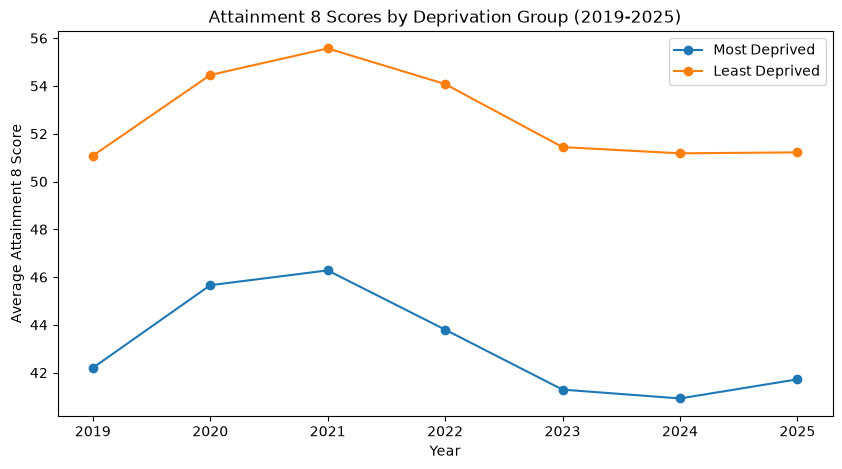

In [13]:
comparison[["Most Deprived", "Least Deprived"]].plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Attainment 8 Scores by Deprivation Group (2019-2025)")
plt.xlabel("Year")
plt.ylabel("Average Attainment 8 Score")
plt.show()

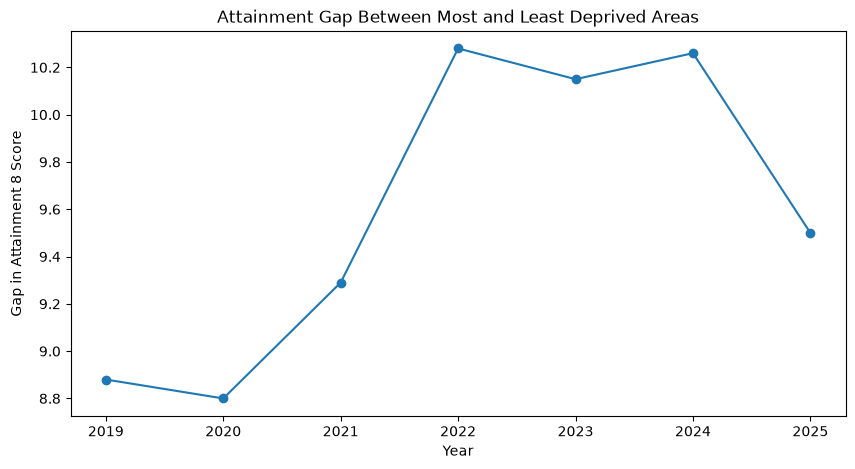

In [14]:
comparison["Gap"].plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Attainment Gap Between Most and Least Deprived Areas")
plt.xlabel("Year")
plt.ylabel("Gap in Attainment 8 Score")
plt.show()

In [15]:
comparison

,Most Deprived,Least Deprived,Gap
end_year,,,
2019,42.20,51.08,8.88
2020,45.66,54.46,8.80
2021,46.28,55.57,9.29
2022,43.80,54.08,10.28
2023,41.29,51.44,10.15
2024,40.92,51.18,10.26
2025,41.72,51.22,9.50


## Methodology

Local Authorities were ranked using their IMD (Index of Multiple Deprivation) score. The 10 most deprived and 10 least deprived Local Authorities were identified using 2019 deprivation scores and tracked across all years from 2019 to 2025.

Average Attainment 8 scores were calculated for each group and compared over time to measure the attainment gap.

## Findings

The average Attainment 8 score was consistently higher in the least deprived Local Authorities than in the most deprived Local Authorities throughout the period 2019 to 2025.

In 2019, the attainment gap was 8.88 points. By 2025, the gap had increased to 9.50 points. The largest gap was observed in 2022 at 10.28 points.

These findings suggest that educational inequality widened following the Covid period and had not returned to pre pandemic levels by 2025.